# N05 · Light from a Star: Flux, Distance and Photon Counting
## How much of the Sun's light would a telescope collect if the Sun sat 1 kpc away?

---

## Learning objectives

After this tutorial you will be able to:

1. State and justify the **basic physical properties** of the Sun (mass, luminosity, radius, effective temperature) and plot its optical/near-infrared **blackbody spectrum**.
2. Explain what the **parsec** is geometrically (via stellar parallax) and what it means to place a star **1 kpc** away.
3. Build the **rest-frame emitted spectrum** (spectral luminosity $L_\lambda$) of the Sun and check that it integrates back to the bolometric luminosity $L_\odot$.
4. Propagate the light to Earth with the **inverse-square law**, first in an **ideal** (vacuum, perfect telescope) case and then in a **fully realistic** case that folds in interstellar dust extinction, the atmosphere, optical throughput and detector quantum efficiency.
5. Convert a spectral flux into a **photon rate** and compute, in a narrow band over one hour, the number of photons **emitted** by the star and **received/detected** by a 10 m telescope.
6. Derive and visualise the **scaling relations** linking emitted luminosity, distance and received light, and explore how the detected signal changes when you vary the **distance** and the **telescope diameter**.

**Mathematics used:** algebra, powers and logarithms, a single definite integral (done numerically), and the geometry of a sphere.
**Physics used:** thermal (blackbody) radiation, conservation of energy / flux, geometric optics.

**Estimated time:** 3–4 hours.

---

> **How to read this notebook.** Each physical question is answered in two passes. We **first** do the clean *ideal* calculation (vacuum, perfect instrument) so the core physics is visible, and **then** we redo it in the *full-realism* case, adding the effects that a real observation must contend with. Compare the two numbers at every step — the gap between them *is* the difference between textbook physics and a real observatory.

---

## 1. Setup, constants and solar reference values

We work in SI units and let `astropy.units` carry the units for us, so every result is dimensionally checked automatically. The fundamental constants are the **NIST CODATA 2022** values ($h$, $c$, $k_B$ are *exact* in the SI since the 2019 redefinition). The solar values are the **IAU 2015 nominal** values.

| Symbol | Quantity | Value |
|--------|----------|-------|
| $h$ | Planck constant | $6.62607015\times10^{-34}\,\mathrm{J\,s}$ |
| $c$ | speed of light | $2.99792458\times10^{8}\,\mathrm{m\,s^{-1}}$ |
| $k_B$ | Boltzmann constant | $1.380649\times10^{-23}\,\mathrm{J\,K^{-1}}$ |
| $\sigma$ | Stefan–Boltzmann constant | $5.6704\times10^{-8}\,\mathrm{W\,m^{-2}\,K^{-4}}$ |
| $L_\odot$ | solar luminosity | $3.828\times10^{26}\,\mathrm{W}$ |
| $R_\odot$ | solar radius | $6.957\times10^{8}\,\mathrm{m}$ |
| $M_\odot$ | solar mass | $1.988\times10^{30}\,\mathrm{kg}$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const

plt.rcParams.update({'figure.figsize': (8, 5), 'font.size': 12,
                     'axes.grid': True, 'grid.alpha': 0.3})

# --- Fundamental constants (NIST CODATA 2022) ---
h       = const.h          # Planck constant
c       = const.c          # speed of light
k_B     = const.k_B        # Boltzmann constant
sigma_sb = const.sigma_sb  # Stefan-Boltzmann constant
b_wien  = const.b_wien     # Wien displacement constant

# --- Solar reference values (IAU 2015 nominal) ---
L_sun = const.L_sun        # 3.828e26 W
R_sun = const.R_sun        # 6.957e8 m
M_sun = const.M_sun        # 1.988e30 kg
T_sun = 5772 * u.K         # IAU nominal solar effective temperature

# --- Distances ---
AU  = const.au             # 1 astronomical unit
pc  = const.pc             # 1 parsec
kpc = 1000 * pc            # 1 kiloparsec

print(f"h   = {h:.6e}")
print(f"c   = {c:.6e}")
print(f"k_B = {k_B:.6e}")
print(f"sigma = {sigma_sb:.6e}")
print(f"L_sun = {L_sun:.4e}")
print(f"R_sun = {R_sun:.4e}")
print(f"M_sun = {M_sun:.4e}")
print(f"T_sun = {T_sun}")
print(f"1 pc  = {pc.to(u.m):.4e} = {pc.to(u.lyr):.3f}")
print(f"1 kpc = {kpc.to(u.m):.4e}")

h   = 6.626070e-34 J s
c   = 2.997925e+08 m / s
k_B = 1.380649e-23 J / K
sigma = 5.670374e-08 W / (m2 K4)
L_sun = 3.8280e+26 W
R_sun = 6.9570e+08 m
M_sun = 1.9884e+30 kg
T_sun = 5772.0 K
1 pc  = 3.0857e+16 m = 3.262 lyr
1 kpc = 3.0857e+19 m


---

## 2. Question 1.a — The basic properties of a Sun-like star

A *Sun-like star* (spectral type G2 V, a main-sequence dwarf) is characterised by four numbers:

| Property | Symbol | Value | What it controls |
|----------|--------|-------|------------------|
| Mass | $M_\odot$ | $1.99\times10^{30}$ kg | gravity, lifetime, fusion rate |
| Radius | $R_\odot$ | $6.96\times10^{8}$ m | emitting surface area |
| Effective temperature | $T_{\rm eff}$ | $5772$ K | colour and peak wavelength |
| Luminosity | $L_\odot$ | $3.83\times10^{26}$ W | total radiated power |

These four are **not independent**. To a good first approximation the Sun radiates like a **blackbody** — a perfect thermal emitter — so its surface brightness follows the **Planck law**, and its total output follows the **Stefan–Boltzmann law**

$$ L = 4\pi R^2\,\sigma\,T_{\rm eff}^4 . $$

The factor $4\pi R^2$ is the surface area of the star (a sphere) and $\sigma T^4$ is the power radiated per unit area. We will (i) define the Planck function, (ii) plot the Sun's spectrum, (iii) find where it peaks (**Wien's law**), and (iv) verify that Stefan–Boltzmann reproduces $L_\odot$.

### 2.1 The Planck function

The **spectral radiance** of a blackbody — the power emitted per unit area, per unit wavelength, per unit solid angle — is

$$ B_\lambda(T) = \frac{2hc^2}{\lambda^5}\,\frac{1}{\exp\!\left(\dfrac{hc}{\lambda k_B T}\right)-1}
\qquad [\,\mathrm{W\,m^{-2}\,nm^{-1}\,sr^{-1}}\,]. $$

The only subtlety in code is that the exponent $hc/(\lambda k_B T)$ becomes huge at short wavelengths, which would overflow `exp`; we clip it at 700 (since $e^{700}$ is already astronomically large) to stay numerically safe.

In [2]:
def B_lambda(lam, T):
    """Planck spectral radiance per unit wavelength.

    Parameters
    ----------
    lam : astropy Quantity (length) - wavelength(s)
    T   : astropy Quantity (temperature)

    Returns
    -------
    Quantity in W m^-2 nm^-1 sr^-1
    """
    lam = lam.to(u.m)
    exponent = (h * c / (lam * k_B * T)).to(u.dimensionless_unscaled).value
    exponent = np.minimum(exponent, 700.0)          # avoid exp overflow
    B = (2.0 * h * c**2 / lam**5) / (np.exp(exponent) - 1.0)
    B = B / u.sr                                     # attach the per-steradian
    return B.to(u.W / u.m**2 / u.nm / u.sr)

# quick check: radiance is positive and finite at 500 nm
print(B_lambda(500*u.nm, T_sun))

26238.54056859585 W / (nm sr m2)


### 2.2 The solar spectrum in the optical / near-infrared

We now plot $B_\lambda(T_\odot)$ across $300$–$2500$ nm, i.e. from the near-ultraviolet, through the **visible** band (380–700 nm, shaded), into the **near-infrared (NIR)**.

**Wien's displacement law** tells us where the spectrum peaks:

$$ \lambda_{\rm peak} = \frac{b}{T}, \qquad b = 2.898\times10^{-3}\,\mathrm{m\,K}. $$

For $T_\odot = 5772$ K this gives $\lambda_{\rm peak}\approx 502$ nm — green light, right in the middle of the visible band and, not coincidentally, where the human eye is most sensitive.

*(A real solar spectrum is not a perfect blackbody: it is crossed by thousands of dark **absorption lines** — Fraunhofer lines: the Balmer hydrogen lines, the Ca H&K doublet, the Na D doublet, the Mg b triplet — where atoms in the cooler outer layers absorb specific wavelengths. The smooth blackbody is the **continuum** those lines are carved out of.)*

Wien peak wavelength: lambda_peak = 502.0 nm


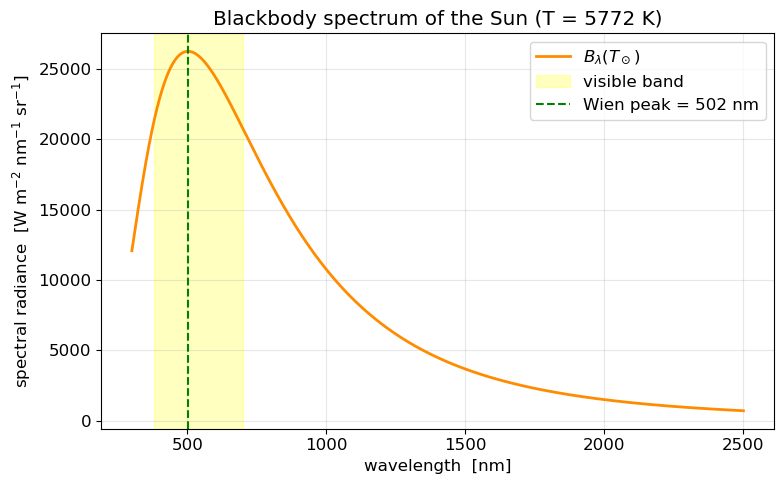

In [3]:
lam_grid = np.linspace(300, 2500, 1000) * u.nm
B_grid   = B_lambda(lam_grid, T_sun)

lam_peak = (b_wien / T_sun).to(u.nm)
print(f"Wien peak wavelength: lambda_peak = {lam_peak:.1f}")

fig, ax = plt.subplots()
ax.plot(lam_grid, B_grid, color='darkorange', lw=2, label=r'$B_\lambda(T_\odot)$')
ax.axvspan(380, 700, color='yellow', alpha=0.25, label='visible band')
ax.axvline(lam_peak.value, color='green', ls='--',
           label=f'Wien peak = {lam_peak:.0f}')
ax.set_xlabel('wavelength  [nm]')
ax.set_ylabel(r'spectral radiance  [W m$^{-2}$ nm$^{-1}$ sr$^{-1}$]')
ax.set_title('Blackbody spectrum of the Sun (T = 5772 K)')
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 Closing the loop: Stefan–Boltzmann

If the Sun is a blackbody, then *integrating* the Planck law over all wavelengths and over the full sphere must give back its luminosity. Stefan–Boltzmann packages that integral into a single formula:

$$ L = 4\pi R_\odot^2\,\sigma\,T_{\rm eff}^4 . $$

Let us evaluate it and compare to the catalogued $L_\odot$. (They agree to better than 1 %; the small residual is because the IAU defines $T_{\rm eff}=5772$ K *from* the nominal $L_\odot$ and $R_\odot$, with rounding.)

In [4]:
L_SB = (4 * np.pi * R_sun**2 * sigma_sb * T_sun**4).to(u.W)

print(f"Stefan-Boltzmann L = 4 pi R^2 sigma T^4 = {L_SB:.4e}")
print(f"Catalogued        L_sun               = {L_sun.to(u.W):.4e}")
print(f"Ratio L_SB / L_sun                    = {(L_SB/L_sun).to(u.dimensionless_unscaled):.4f}")

Stefan-Boltzmann L = 4 pi R^2 sigma T^4 = 3.8280e+26 W
Catalogued        L_sun               = 3.8280e+26 W
Ratio L_SB / L_sun                    = 1.0000


---

## 3. Question 1.b — Put the Sun at 1 kpc, and write down the emitted spectrum

### 3.1 What is a parsec, and what does "1 kpc away" mean?

Astronomers measure distance with **parallax**: as the Earth orbits the Sun, a nearby star appears to shift back and forth against the far background. Over six months the Earth moves by $2\,\mathrm{AU}$ (the diameter of its orbit), and the star's apparent half-shift is the **parallax angle** $p$.

The **parsec** is *defined* as the distance at which a star shows a parallax of **1 arcsecond** ($1'' = 1/3600$ of a degree) for a baseline of **1 AU**:

$$ d\,[\mathrm{pc}] = \frac{1}{p\,['']}, \qquad 1\,\mathrm{pc} = \frac{1\,\mathrm{AU}}{1''\;(\text{in radians})} = 3.086\times10^{16}\,\mathrm{m} \approx 3.26\ \text{light-years}. $$

A **kiloparsec** is $1\,\mathrm{kpc} = 1000\,\mathrm{pc} \approx 3.086\times10^{19}$ m. For scale: the Sun's nearest neighbour (Proxima Centauri) is $1.3$ pc away, and the Milky Way's disk is $\sim 30$ kpc across — so a star at **1 kpc** is a *typical, relatively nearby star within our own Galaxy*, well inside the Milky Way.

**Important consequence:** 1 kpc is a *galactic* distance, not a *cosmological* one. The recession velocity from cosmic expansion at 1 kpc is $\sim 0.07\,\mathrm{km/s}$ — utterly negligible. So the **redshift is essentially zero**: the wavelengths we receive are the same as those emitted. The "rest-frame emitted spectrum" and the "observed-frame spectrum" live on the *same wavelength grid*; only the **brightness** changes with distance.

In [5]:
# Verify the geometric definition of the parsec: 1 pc = 1 AU / (1 arcsec in radians)
one_arcsec_rad = (1 * u.arcsec).to(u.rad).value
pc_from_def = (AU / one_arcsec_rad).to(u.m)
print(f"1 AU                       = {AU.to(u.m):.4e}")
print(f"1 arcsec                   = {one_arcsec_rad:.4e} rad")
print(f"1 pc  (from 1 AU / 1 arcsec) = {pc_from_def:.4e}")
print(f"1 pc  (astropy)             = {pc.to(u.m):.4e}")

# Negligible cosmological redshift check (Hubble flow, H0 ~ 70 km/s/Mpc)
H0 = 70 * u.km/u.s/u.Mpc
v_recess = (H0 * kpc).to(u.km/u.s)
print(f"\nRecession velocity at 1 kpc: v = H0 * d = {v_recess:.3f}  -> redshift z = {(v_recess/c).to(u.dimensionless_unscaled):.2e} (negligible)")

1 AU                       = 1.4960e+11 m
1 arcsec                   = 4.8481e-06 rad
1 pc  (from 1 AU / 1 arcsec) = 3.0857e+16 m
1 pc  (astropy)             = 3.0857e+16 m

Recession velocity at 1 kpc: v = H0 * d = 0.070 km / s  -> redshift z = 2.33e-07 (negligible)


### 3.2 The rest-frame emitted spectrum: spectral luminosity $L_\lambda$

The Planck function $B_\lambda$ is a *surface brightness* (per unit area, per steradian). To get the **total power the star emits per unit wavelength** — its **spectral luminosity** $L_\lambda$ — we integrate over the stellar surface and over the outward hemisphere of directions.

- Integrating the radiance over the emitting hemisphere converts radiance to **surface flux**: $F_\lambda^{\rm surf} = \pi\,B_\lambda$. (The factor $\pi$, with units of steradian, is $\int\cos\theta\,d\Omega$ over a hemisphere.)
- Multiplying by the surface area $4\pi R_\odot^2$ gives the spectral luminosity:

$$ \boxed{\,L_\lambda = 4\pi R_\odot^2\cdot \pi B_\lambda(T) = 4\pi^2 R_\odot^2\,B_\lambda(T)\,}\qquad [\,\mathrm{W\,nm^{-1}}\,]. $$

This is the *rest-frame emitted spectrum* the question asks for: energy per second per nanometre, leaving the star in all directions. As a self-consistency check, $\int_0^\infty L_\lambda\,d\lambda$ must equal the bolometric luminosity $L_\odot$.

Integral of L_lambda over all wavelengths = 3.8280e+26 W
Catalogued L_sun                          = 3.8280e+26 W
Ratio                                     = 1.0000


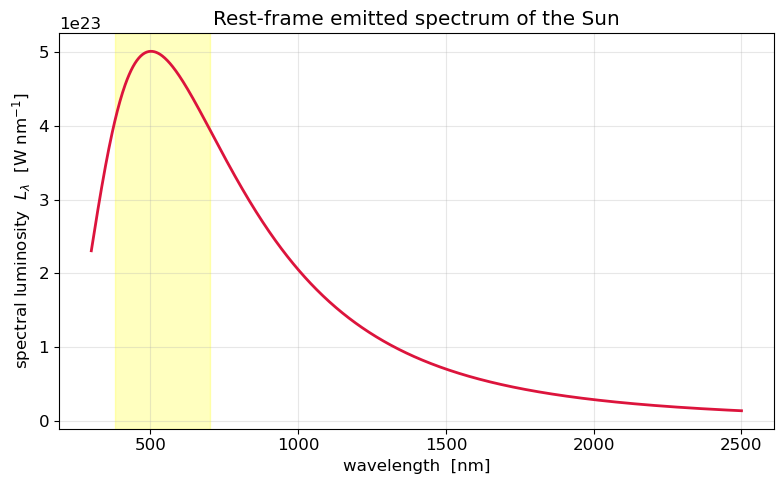

In [6]:
def L_lambda(lam, T=T_sun, R=R_sun):
    """Spectral luminosity of a blackbody star [W / nm]."""
    F_surf = np.pi * u.sr * B_lambda(lam, T)   # surface flux  [W m^-2 nm^-1]
    return (4 * np.pi * R**2 * F_surf).to(u.W / u.nm)

# Integrate L_lambda over a very wide grid and compare with L_sun.
# (NumPy 2: np.trapezoid, not np.trapz.)
lam_wide = np.logspace(1, 6, 20000) * u.nm        # 10 nm -> 1 mm
Llam_wide = L_lambda(lam_wide, T_sun)
L_integrated = np.trapezoid(Llam_wide.value, lam_wide.to(u.nm).value) * (u.W/u.nm*u.nm)

print(f"Integral of L_lambda over all wavelengths = {L_integrated.to(u.W):.4e}")
print(f"Catalogued L_sun                          = {L_sun.to(u.W):.4e}")
print(f"Ratio                                     = {(L_integrated/L_sun).to(u.dimensionless_unscaled):.4f}")

# Plot the emitted spectral luminosity over the optical/NIR
Llam_grid = L_lambda(lam_grid, T_sun)
fig, ax = plt.subplots()
ax.plot(lam_grid, Llam_grid.to(u.W/u.nm), color='crimson', lw=2)
ax.axvspan(380, 700, color='yellow', alpha=0.25)
ax.set_xlabel('wavelength  [nm]')
ax.set_ylabel(r'spectral luminosity  $L_\lambda$  [W nm$^{-1}$]')
ax.set_title('Rest-frame emitted spectrum of the Sun')
plt.tight_layout()
plt.show()

---

## 4. Question 1.c — Propagate the light to Earth and observe it with a 10 m telescope

The star radiates $L_\lambda$ in **all directions**. By the time the light reaches Earth, that power has spread over an enormous sphere. How much lands on our telescope?

We answer this **twice**: first the **ideal** case (empty space, perfect telescope), then the **fully realistic** case.

### 4.1 STEP 1 — Ideal case: the inverse-square law and a perfect aperture

Energy is conserved, so the power $L_\lambda\,d\lambda$ emitted in a wavelength bin must, at distance $d$, be spread uniformly over a sphere of area $4\pi d^2$. The power arriving **per unit area** — the **spectral flux density** — is therefore

$$ f_\lambda = \frac{L_\lambda}{4\pi d^2} \qquad [\,\mathrm{W\,m^{-2}\,nm^{-1}}\,]. $$

This $1/d^2$ falloff is the **inverse-square law**: double the distance, quarter the flux. A telescope of diameter $D$ presents a **collecting area**

$$ A_{\rm tel} = \pi\left(\frac{D}{2}\right)^2, $$

and (ideally) intercepts the power $f_\lambda\,A_{\rm tel}\,d\lambda$. A bigger mirror is quite literally a bigger bucket for catching photons.

*(Aside — resolution. A telescope is not only a light bucket; diffraction sets the finest angle it can resolve, $\theta_{\rm min}\approx 1.22\,\lambda/D$. For $D=10$ m at $\lambda=550$ nm this is $\sim0.014''$ — but Earth's atmosphere blurs ground-based images to $\sim1''$ unless adaptive optics is used. Resolution does not change the *total* number of photons collected, which is what we track here.)*

Diffraction limit at 550 nm: theta ~ 1.22 lambda/D = 0.0138 arcsec


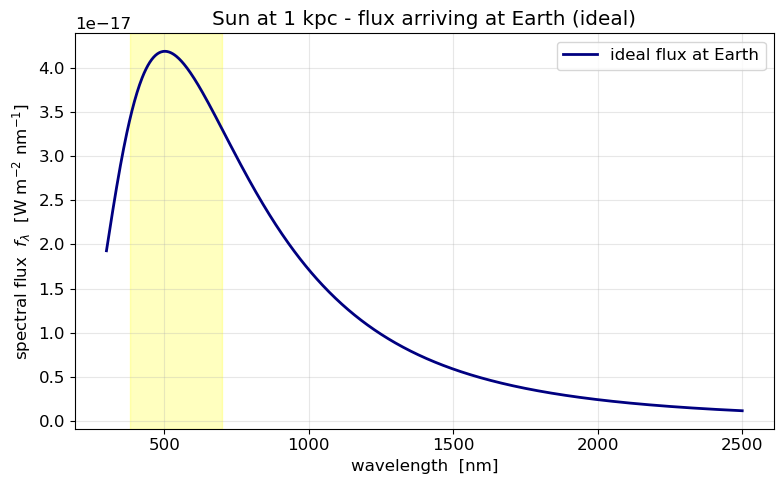

In [7]:
d = 1 * kpc                     # put the Sun at 1 kpc
D_tel = 10 * u.m                 # telescope diameter
A_tel = np.pi * (D_tel/2)**2     # collecting area
print(f"Collecting area of a {D_tel:.0f} telescope: A = {A_tel:.2f}")

# Ideal spectral flux at Earth (vacuum, no losses)
f_lam_ideal = (L_lambda(lam_grid, T_sun) / (4*np.pi*d**2)).to(u.W/u.m**2/u.nm)

# Diffraction limit at 550 nm (aside)
theta_diff = (1.22 * (550*u.nm) / D_tel).to(u.arcsec, equivalencies=u.dimensionless_angles())
print(f"Diffraction limit at 550 nm: theta ~ 1.22 lambda/D = {theta_diff:.4f}")

fig, ax = plt.subplots()
ax.plot(lam_grid, f_lam_ideal, color='navy', lw=2, label='ideal flux at Earth')
ax.axvspan(380, 700, color='yellow', alpha=0.25)
ax.set_xlabel('wavelength  [nm]')
ax.set_ylabel(r'spectral flux  $f_\lambda$  [W m$^{-2}$ nm$^{-1}$]')
ax.set_title('Sun at 1 kpc - flux arriving at Earth (ideal)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 STEP 2 — Full realism: dust, atmosphere, optics and detector

Between the star and our recorded image, the light is attenuated by four effects, each a multiplicative factor between 0 and 1:

1. **Interstellar extinction (dust).** The Milky Way's disk is filled with dust grains that absorb and scatter starlight, preferentially in the blue (this also *reddens* the star). The dimming in magnitudes is $A_\lambda$; in the disk a rough rule is $A_V \approx 1$ mag per kpc in the $V$ band. The transmitted fraction is $10^{-A_\lambda/2.5}$. We use the standard **Cardelli, Clayton & Mathis (1989)** extinction curve with $R_V = 3.1$.
2. **Atmospheric transmission $T_{\rm atm}(\lambda)$.** For a ground-based telescope, Rayleigh scattering, aerosols and molecular absorption remove light (more in the blue). We use a simple analytic model for a good site at zenith.
3. **Optical throughput $\eta$.** Every mirror and lens reflects/transmits less than 100 %; a real system delivers maybe $\eta\sim0.5$ of the light to the detector.
4. **Detector quantum efficiency $\mathrm{QE}(\lambda)$.** A CCD converts only a fraction of arriving photons into measured electrons, peaking around 80–90 % in the red and falling off in the blue and NIR.

The flux *delivered to the detector* is

$$ f_\lambda^{\rm det} = f_\lambda^{\rm ideal}\;\underbrace{10^{-A_\lambda/2.5}}_{\rm dust}\;\underbrace{T_{\rm atm}(\lambda)}_{\rm sky}\;\underbrace{\eta}_{\rm optics}\;\underbrace{\mathrm{QE}(\lambda)}_{\rm detector}. $$

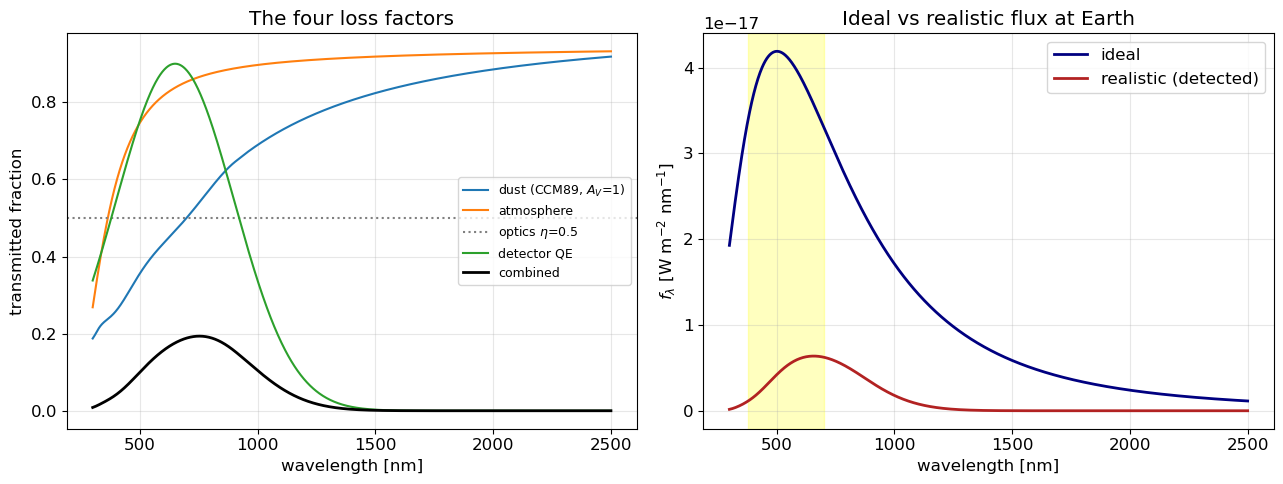

At 550 nm: dust=0.399, atm=0.789, eta=0.50, QE=0.832  ->  combined loss factor = 0.1311


In [8]:
from dust_extinction.parameter_averages import CCM89

# 1. Interstellar dust extinction (CCM89, R_V = 3.1, A_V = 1 mag at 1 kpc)
A_V = 1.0
ext_model = CCM89(Rv=3.1)
# CCM89 is valid 0.30-3.33 micron^-1, i.e. ~300 nm - 3.3 micron; our 300-2500 nm grid fits.
trans_dust = ext_model.extinguish(lam_grid, Av=A_V)          # = 10^(-0.4 A_lambda)

# 2. Atmospheric transmission (toy model for a good site, airmass=1)
def atm_transmission(lam, airmass=1.0):
    lam_um = lam.to(u.um).value
    tau = 0.0089*lam_um**-4 + 0.05*lam_um**-1 + 0.05      # Rayleigh + aerosol + grey
    return np.exp(-tau*airmass)
trans_atm = atm_transmission(lam_grid)

# 3. Optical throughput (grey)
eta = 0.50

# 4. Detector quantum efficiency (toy CCD, peaks ~650 nm)
def detector_QE(lam):
    lam_nm = lam.to(u.nm).value
    return 0.90 * np.exp(-0.5*((lam_nm - 650.0)/250.0)**2)
qe = detector_QE(lam_grid)

# Combined transmission and the detector-level flux
total_trans = trans_dust * trans_atm * eta * qe
f_lam_real  = f_lam_ideal * total_trans

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(lam_grid, trans_dust, label='dust (CCM89, $A_V$=1)')
axes[0].plot(lam_grid, trans_atm,  label='atmosphere')
axes[0].axhline(eta, color='gray', ls=':', label=r'optics $\eta$=0.5')
axes[0].plot(lam_grid, qe, label='detector QE')
axes[0].plot(lam_grid, total_trans, 'k-', lw=2, label='combined')
axes[0].set_xlabel('wavelength [nm]'); axes[0].set_ylabel('transmitted fraction')
axes[0].set_title('The four loss factors'); axes[0].legend(fontsize=9)

axes[1].plot(lam_grid, f_lam_ideal, color='navy', lw=2, label='ideal')
axes[1].plot(lam_grid, f_lam_real, color='firebrick', lw=2, label='realistic (detected)')
axes[1].axvspan(380, 700, color='yellow', alpha=0.25)
axes[1].set_xlabel('wavelength [nm]'); axes[1].set_ylabel(r'$f_\lambda$ [W m$^{-2}$ nm$^{-1}$]')
axes[1].set_title('Ideal vs realistic flux at Earth'); axes[1].legend()
plt.tight_layout(); plt.show()

# loss factor in the V band (~550 nm)
iV = np.argmin(np.abs(lam_grid - 550*u.nm))
print(f"At 550 nm: dust={trans_dust[iV]:.3f}, atm={trans_atm[iV]:.3f}, "
      f"eta={eta:.2f}, QE={qe[iV]:.3f}  ->  combined loss factor = {total_trans[iV]:.4f}")

### 4.3 A familiar yardstick: the apparent magnitude

Astronomers compress "how bright does it look" into the **apparent magnitude** $m$ (a logarithmic, *backwards* scale: smaller = brighter). It relates to the **absolute magnitude** $M$ (the brightness the star *would* have at the reference distance of 10 pc) through the **distance modulus**:

$$ m = M + 5\log_{10}\!\left(\frac{d}{10\,\mathrm{pc}}\right) + A . $$

For the Sun in the $V$ band, $M_V^\odot = 4.83$. At $d=1$ kpc the distance modulus is $5\log_{10}(1000/10) = 5\log_{10}(100) = 10$ mag.
- **Ideal** (no dust): $m_V = 4.83 + 10 = 14.83$.
- **Realistic** (with $A_V=1$): $m_V = 4.83 + 10 + 1 = 15.83$.

A 10 m-class telescope reaches well past $m_V\sim27$, so the Sun at 1 kpc would be an **easy, bright target** — but far too faint to see with the naked eye (limit $m_V\approx6$).

In [9]:
M_V_sun = 4.83
dist_modulus = 5*np.log10((d/(10*u.pc)).to(u.dimensionless_unscaled).value)
m_V_ideal = M_V_sun + dist_modulus
m_V_real  = M_V_sun + dist_modulus + A_V
print(f"Distance modulus at 1 kpc : {dist_modulus:.2f} mag")
print(f"Apparent magnitude (ideal) : m_V = {m_V_ideal:.2f}")
print(f"Apparent magnitude (real)  : m_V = {m_V_real:.2f}")
print(f"Naked-eye limit ~6 ; 10 m telescope limit ~27  ->  easily detected, invisible to the eye")

Distance modulus at 1 kpc : 10.00 mag
Apparent magnitude (ideal) : m_V = 14.83
Apparent magnitude (real)  : m_V = 15.83
Naked-eye limit ~6 ; 10 m telescope limit ~27  ->  easily detected, invisible to the eye


---

## 5. Question 1.d — Counting photons in a narrow band over one hour

Light is **quantised**: it arrives in photons, each carrying energy

$$ E_\gamma = \frac{hc}{\lambda}. $$

To turn a power (W = J/s) into a **photon rate** (photons/s) we divide by the energy per photon, then multiply by the exposure time. We work in a **narrow band** of width $\Delta\lambda$ centred on $\lambda_0 = 550$ nm (green / $V$ band), so $L_\lambda$, $f_\lambda$ and $E_\gamma$ are all approximately constant across the band, and the integral $\int L_\lambda\,d\lambda$ is just $L_\lambda(\lambda_0)\,\Delta\lambda$.

We take $\Delta\lambda = 10$ nm and an exposure $t = 1$ hour $= 3600$ s.

| Quantity | Formula |
|----------|---------|
| Photon energy | $E_\gamma = hc/\lambda_0$ |
| **Emitted** by the star | $N_{\rm emit} = \dfrac{L_\lambda(\lambda_0)\,\Delta\lambda}{E_\gamma}\,t$ |
| **Received (ideal)** at the aperture | $N_{\rm rec}^{\rm ideal} = \dfrac{f_\lambda^{\rm ideal}(\lambda_0)\,A_{\rm tel}\,\Delta\lambda}{E_\gamma}\,t$ |
| **Detected (realistic)** | $N_{\rm det}^{\rm real} = N_{\rm rec}^{\rm ideal}\times(\text{dust}\cdot T_{\rm atm}\cdot\eta\cdot\mathrm{QE})$ |

In [10]:
lam0   = 550 * u.nm
dlam   = 10 * u.nm
t_exp  = 1 * u.hour

E_gamma = (h * c / lam0).to(u.J)
print(f"Energy of one 550 nm photon: E = hc/lambda = {E_gamma:.3e} = {E_gamma.to(u.eV):.3f}")

# --- STEP 1: ideal ---
Llam0      = L_lambda(lam0, T_sun)
flam0_ideal = (Llam0 / (4*np.pi*d**2)).to(u.W/u.m**2/u.nm)

N_emit = (Llam0 * dlam / E_gamma * t_exp).to(u.dimensionless_unscaled)
N_rec_ideal = (flam0_ideal * A_tel * dlam / E_gamma * t_exp).to(u.dimensionless_unscaled)

# --- STEP 2: full realism (reuse the loss factors evaluated at 550 nm) ---
loss = (ext_model.extinguish(lam0, Av=A_V)
        * atm_transmission(lam0) * eta * detector_QE(lam0))
N_det_real = N_rec_ideal * loss

print(f"\nBand: lambda0 = {lam0}, width dlam = {dlam}, exposure t = {t_exp}")
print(f"  Photons EMITTED by the star in 1 h        : N_emit       = {N_emit:.3e}")
print(f"  Photons RECEIVED at the aperture (ideal)  : N_rec_ideal  = {N_rec_ideal:.3e}")
print(f"  Combined loss factor at 550 nm            : {loss:.4f}")
print(f"  Photons DETECTED (full realism)           : N_det_real   = {N_det_real:.3e}")
print(f"\n  Fraction of emitted photons that we detect: {(N_det_real/N_emit):.3e}")
print(f"  -> roughly 1 detected for every {1/(N_det_real/N_emit):.1e} emitted")

Energy of one 550 nm photon: E = hc/lambda = 3.612e-19 J = 2.254 eV

Band: lambda0 = 550.0 nm, width dlam = 10.0 nm, exposure t = 1.0 h
  Photons EMITTED by the star in 1 h        : N_emit       = 4.901e+46
  Photons RECEIVED at the aperture (ideal)  : N_rec_ideal  = 3.217e+08
  Combined loss factor at 550 nm            : 0.1305
  Photons DETECTED (full realism)           : N_det_real   = 4.197e+07

  Fraction of emitted photons that we detect: 8.564e-40
  -> roughly 1 detected for every 1.2e+39 emitted


---

## 6. Question 2 — The relation between emitted light, distance and received light

Collecting everything above, the number of photons we **detect** in a fixed band and exposure is

$$ N_{\rm det} \;=\; \underbrace{\frac{L_\lambda\,\Delta\lambda}{E_\gamma}\,t}_{\text{emitted rate}}\;\times\;\underbrace{\frac{A_{\rm tel}}{4\pi d^2}}_{\text{geometric capture}}\;\times\;\underbrace{(\text{loss factors})}_{\le 1}. $$

Two clean scaling laws fall out, holding everything else fixed:

$$ \boxed{\,N_{\rm det} \propto \dfrac{L}{d^{2}}\,}\qquad\text{and}\qquad \boxed{\,N_{\rm det}\propto A_{\rm tel}\propto D^{2}\,}. $$

- **Distance:** the inverse-square law. Move a source 10× farther and it delivers $100\times$ fewer photons. On a log–log plot, $N$ vs $d$ is a straight line of **slope $-2$**.
- **Telescope:** photon count grows as the **collecting area**, i.e. as the **square of the diameter**. A 10 m mirror gathers $(10/1)^2 = 100\times$ more light than a 1 m mirror. On a log–log plot, $N$ vs $D$ has **slope $+2$**.

The realistic curve is the ideal curve scaled down by the (here roughly constant) loss factor — a *parallel* line on a log scale, not a change of slope.

### 6.1 Question 2.a — Vary the distance and the telescope diameter

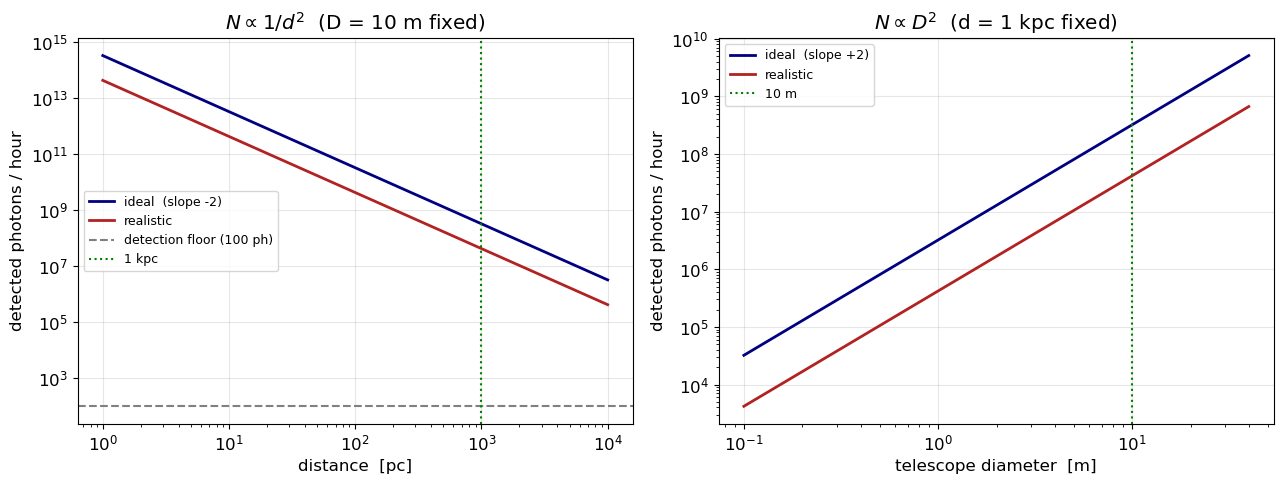

Fitted log-log slope  N vs d : -2.000  (expected -2)
Fitted log-log slope  N vs D : +2.000  (expected +2)


In [11]:
# Helper: detected photons/hour in the 550 nm, 10 nm band, as a function of d and D
loss550 = float(ext_model.extinguish(lam0, Av=A_V) * atm_transmission(lam0) * eta * detector_QE(lam0))

def detected_photons(d_val, D_val, include_losses=True):
    A = np.pi*(D_val/2)**2
    flam = Llam0 / (4*np.pi*d_val**2)
    N = (flam * A * dlam / E_gamma * t_exp).to(u.dimensionless_unscaled).value
    return N*loss550 if include_losses else N

# (a) vary distance, fixed D = 10 m
d_arr = np.logspace(0, 4, 200) * u.pc        # 1 pc -> 10 kpc
N_vs_d_ideal = np.array([detected_photons(dd, D_tel, False) for dd in d_arr])
N_vs_d_real  = np.array([detected_photons(dd, D_tel, True)  for dd in d_arr])

# (b) vary diameter, fixed d = 1 kpc
D_arr = np.logspace(-1, 1.6, 200) * u.m      # 0.1 m -> ~40 m
N_vs_D_ideal = np.array([detected_photons(d, DD, False) for DD in D_arr])
N_vs_D_real  = np.array([detected_photons(d, DD, True)  for DD in D_arr])

N_thresh = 100.0   # crude detection floor: ~100 photons for a confident measurement

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].loglog(d_arr, N_vs_d_ideal, color='navy', lw=2, label='ideal  (slope -2)')
axes[0].loglog(d_arr, N_vs_d_real,  color='firebrick', lw=2, label='realistic')
axes[0].axhline(N_thresh, color='gray', ls='--', label=f'detection floor ({N_thresh:.0f} ph)')
axes[0].axvline(1000, color='green', ls=':', label='1 kpc')
axes[0].set_xlabel('distance  [pc]'); axes[0].set_ylabel('detected photons / hour')
axes[0].set_title(r'$N \propto 1/d^2$  (D = 10 m fixed)'); axes[0].legend(fontsize=9)

axes[1].loglog(D_arr, N_vs_D_ideal, color='navy', lw=2, label='ideal  (slope +2)')
axes[1].loglog(D_arr, N_vs_D_real,  color='firebrick', lw=2, label='realistic')
axes[1].axvline(10, color='green', ls=':', label='10 m')
axes[1].set_xlabel('telescope diameter  [m]'); axes[1].set_ylabel('detected photons / hour')
axes[1].set_title(r'$N \propto D^2$  (d = 1 kpc fixed)'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

# numerically confirm the slopes
slope_d = np.polyfit(np.log10(d_arr.value), np.log10(N_vs_d_real), 1)[0]
slope_D = np.polyfit(np.log10(D_arr.value), np.log10(N_vs_D_real), 1)[0]
print(f"Fitted log-log slope  N vs d : {slope_d:+.3f}  (expected -2)")
print(f"Fitted log-log slope  N vs D : {slope_D:+.3f}  (expected +2)")

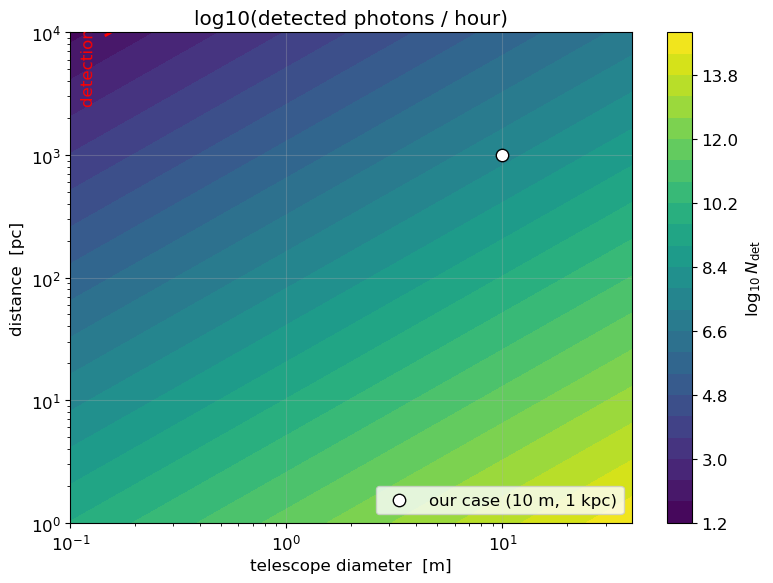

Reading the map: moving UP (farther) costs photons as 1/d^2;
moving RIGHT (bigger mirror) gains photons as D^2. The red line is the
break-even contour where we just reach the detection floor.


In [12]:
# 2-D view: detected photons/hour over the (distance, diameter) plane
dd_grid = np.logspace(0, 4, 120) * u.pc
DD_grid = np.logspace(-1, 1.6, 120) * u.m
DDm, ddm = np.meshgrid(DD_grid, dd_grid)
Z = np.array([[detected_photons(dv, Dv, True) for Dv in DD_grid] for dv in dd_grid])

fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(DD_grid.value, dd_grid.value, np.log10(Z), levels=25, cmap='viridis')
cs = ax.contour(DD_grid.value, dd_grid.value, np.log10(Z),
                levels=[np.log10(N_thresh)], colors='red', linewidths=2)
ax.clabel(cs, fmt={np.log10(N_thresh): 'detection floor'})
ax.scatter([10], [1000], color='white', edgecolor='k', s=80, zorder=5, label='our case (10 m, 1 kpc)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('telescope diameter  [m]'); ax.set_ylabel('distance  [pc]')
ax.set_title('log10(detected photons / hour)')
fig.colorbar(cf, label=r'$\log_{10} N_{\rm det}$'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

print("Reading the map: moving UP (farther) costs photons as 1/d^2;")
print("moving RIGHT (bigger mirror) gains photons as D^2. The red line is the")
print("break-even contour where we just reach the detection floor.")

---

## 7. Summary of results

The cell below gathers every number computed above into one table.

In [13]:
print("="*64)
print(" SUMMARY - Sun-like star observed at 1 kpc with a 10 m telescope")
print("="*64)
print(f"{'Mass M_sun':35s} {M_sun.to(u.kg):.3e}")
print(f"{'Radius R_sun':35s} {R_sun.to(u.m):.3e}")
print(f"{'Eff. temperature T_eff':35s} {T_sun}")
print(f"{'Luminosity L_sun':35s} {L_sun.to(u.W):.3e}")
print(f"{'Wien peak wavelength':35s} {lam_peak:.1f}")
print("-"*64)
print(f"{'Distance d':35s} {d.to(u.kpc):.0f}  = {d.to(u.m):.3e}")
print(f"{'Telescope diameter D':35s} {D_tel:.0f}")
print(f"{'Collecting area A_tel':35s} {A_tel:.2f}")
print(f"{'Apparent mag (ideal)':35s} m_V = {m_V_ideal:.2f}")
print(f"{'Apparent mag (realistic)':35s} m_V = {m_V_real:.2f}")
print("-"*64)
print(f"   Band: {lam0:.0f} +/- {dlam/2:.0f},  exposure {t_exp}")
print(f"{'Photons emitted by star':35s} {N_emit:.3e}")
print(f"{'Photons received (ideal aperture)':35s} {N_rec_ideal:.3e}")
print(f"{'Photons detected (full realism)':35s} {N_det_real:.3e}")
print(f"{'Combined loss factor @550 nm':35s} {loss550:.4f}")
print("="*64)

 SUMMARY - Sun-like star observed at 1 kpc with a 10 m telescope
Mass M_sun                          1.988e+30 kg
Radius R_sun                        6.957e+08 m
Eff. temperature T_eff              5772.0 K
Luminosity L_sun                    3.828e+26 W
Wien peak wavelength                502.0 nm
----------------------------------------------------------------
Distance d                          1 kpc  = 3.086e+19 m
Telescope diameter D                10 m
Apparent mag (ideal)                m_V = 14.83
Apparent mag (realistic)            m_V = 15.83
----------------------------------------------------------------
   Band: 550 nm +/- 5 nm,  exposure 1.0 h
Photons emitted by star             4.901e+46
Photons received (ideal aperture)   3.217e+08
Photons detected (full realism)     4.197e+07
Combined loss factor @550 nm        0.1305


---

## 8. Exercises — your turn

Work these in fresh cells. They reuse the functions you have already written.

1. **A cooler star.** Replace the Sun with a red M-dwarf: $T = 3200$ K, $R = 0.3\,R_\odot$. Where does its spectrum peak (Wien)? Recompute its luminosity (Stefan–Boltzmann) and the photons detected at 1 kpc with the 10 m telescope, *in the same 550 nm band*. Is it easier or harder to detect than the Sun, and why? (Hint: think about where an M-dwarf emits most of its light.)

2. **Go to space.** A space telescope sees **no atmosphere and no extra optics losses you can avoid**, but interstellar dust is still there. Recompute $N_{\rm det}$ for the Sun at 1 kpc dropping only the atmospheric term. By what factor does the photon count improve?

3. **How far can we see it?** Using `detected_photons`, find the distance at which the Sun's detected photon count in 1 hour drops to the detection floor of 100 photons, for $D = 1$ m, $10$ m and $39$ m (the ELT). Comment on how the reach scales with $D$.

4. **Widen the band.** Redo Question 1.d with $\Delta\lambda = 100$ nm instead of 10 nm. Does the photon count scale exactly linearly with $\Delta\lambda$? When would the narrow-band approximation ($L_\lambda \approx$ const across the band) start to break down?

---

### Key formulae to remember

| Concept | Formula |
|---------|---------|
| Planck radiance | $B_\lambda = \dfrac{2hc^2}{\lambda^5}\dfrac{1}{e^{hc/\lambda k_BT}-1}$ |
| Stefan–Boltzmann | $L = 4\pi R^2\sigma T^4$ |
| Wien's law | $\lambda_{\rm peak} = b/T$ |
| Spectral luminosity | $L_\lambda = 4\pi^2 R^2 B_\lambda$ |
| Inverse-square flux | $f_\lambda = L_\lambda/(4\pi d^2)$ |
| Collecting area | $A = \pi (D/2)^2$ |
| Photon energy | $E_\gamma = hc/\lambda$ |
| Photon count | $N = \dfrac{f_\lambda A\,\Delta\lambda}{E_\gamma}\,t\times(\text{losses})$ |
| Distance modulus | $m = M + 5\log_{10}(d/10\,\mathrm{pc}) + A$ |

**Take-away:** the brightness of a star at your telescope is set by a tug-of-war between how much it *emits* ($L$), how *far* it is ($1/d^2$), and how *big* your mirror is ($D^2$) — and a real measurement then pays a tax (dust, sky, optics, detector) on top.